In [15]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=RuntimeWarning)


In [16]:
# =============================================================================
# CONFIGURATION  –  edit this cell only
# =============================================================================

MIN_FRAME      = 20
MAX_FRAME      = 100
OUTPUT_DIR     = 'Output__'
CHANNEL_SUFFIX = 'Ch1'     # set to '' if unused
CWD            = os.getcwd()

DATA_CONFIG = {
    'WT': {
        'path': 'WT',
        'drug_suffix': 'psi',
        'slices': {'data1': [1,2,3], 'data2': [1,2,3,4], 'data3': [1,2,3,4]},
    },
    'AV': {
        'path': 'Antagonist- Volinanserin',
        'drug_suffix': 'psi+antag',
        'slices': {'data1': [1,2,3,4], 'data2': [1,2,3,4]},
    },
    'IP': {
        'path': 'IP3R2 cKO',
        'drug_suffix': 'psi',
        'slices': {'data1': [2,4,5], 'data2': [1,2,3]},
    },
    'CE': {
        'path': 'CalEx',
        'drug_suffix': 'psi',
        'slices': {'data1': [1,2,3,4,5,6], 'data2': [1,2,3]},
    },
}

ALL_FEATURES = [
    "Curve - Max Df", "Curve - Max Dff",
    "Curve - dat AUC", "Curve - df AUC", "Curve - dff AUC",
    "Basic - Area", "Basic - Perimeter (only for 2D video)", "Basic - Circularity",
    "Curve - Duration of visualized event overlay",
    "Curve - Duration 50% to 50% based on averge dF/F",
    "Curve - Duration 10% to 10% based on averge dF/F",
    "Curve - Rising duration 10% to 90% based on averge dF/F",
    "Curve - Decaying duration 90% to 10% based on averge dF/F",
    "Network - number of events in the same location",
    "Network - number of events in the same location with similar size only",
    "Network - maximum number of events appearing at the same time",
]

ALPHA         = 0.05
CONTROL_GROUP = 'WT'
BIN_SIZES     = [5, 10, 20]   # frame bin widths for CSV exports

# Plotting
COLORS      = {'WT': '#4878CF', 'AV': '#6ACC65', 'IP': '#D65F5F', 'CE': '#B47CC7'}
GROUP_ORDER = list(DATA_CONFIG.keys())

# Short display labels for plots (avoids truncation of long feature names)
FEATURE_LABELS = {
    "Curve - Max Df":                                                    "Max ΔF",
    "Curve - Max Dff":                                                   "Max ΔF/F",
    "Curve - dat AUC":                                                   "AUC (raw)",
    "Curve - df AUC":                                                    "AUC (ΔF)",
    "Curve - dff AUC":                                                   "AUC (ΔF/F)",
    "Basic - Area":                                                      "Area",
    "Basic - Perimeter (only for 2D video)":                             "Perimeter",
    "Basic - Circularity":                                               "Circularity",
    "Curve - Duration of visualized event overlay":                      "Duration (overlay)",
    "Curve - Duration 50% to 50% based on averge dF/F":                 "Duration (50–50%)",
    "Curve - Duration 10% to 10% based on averge dF/F":                 "Duration (10–10%)",
    "Curve - Rising duration 10% to 90% based on averge dF/F":          "Rise time (10–90%)",
    "Curve - Decaying duration 90% to 10% based on averge dF/F":        "Decay time (90–10%)",
    "Network - number of events in the same location":                   "Co-location events",
    "Network - number of events in the same location with similar size only": "Co-location (same size)",
    "Network - maximum number of events appearing at the same time":     "Max simultaneous events",
}

def _feat_label(feat):
    """Return short display label for a feature name."""
    return FEATURE_LABELS.get(feat, feat.split(' - ')[-1][:40])


In [17]:
# =============================================================================
# DATA LOADING AND NORMALISATION
# =============================================================================

_DROP_COLS = {'Channel', 'Index', 'Curve - P Value on max Dff (-log10)', 'Curve - Decay tau'}
_META_COLS = {'Starting Frame', 'data_folder', 'slice_num'}


def _file_paths(config):
    """Yield (baseline_path, drug_path, washout_path, subfolder, slice_num)."""
    ch = f'_{CHANNEL_SUFFIX}' if CHANNEL_SUFFIX else ''
    for subfolder, nums in config['slices'].items():
        folder = os.path.join(CWD, OUTPUT_DIR, config['path'], subfolder)
        for n in nums:
            yield (
                os.path.join(folder, f'slice{n}_baseline_AQuA2{ch}.csv'),
                os.path.join(folder, f'slice{n}_{config["drug_suffix"]}_AQuA2{ch}.csv'),
                os.path.join(folder, f'slice{n}_washout_AQuA2{ch}.csv'),
                subfolder, n,
            )


def _load_file(path):
    """Load one AQuA2 CSV → tidy DataFrame filtered to [MIN_FRAME, MAX_FRAME]."""
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path, header=None).set_index(0).T.reset_index(drop=True)
    df = df.drop(columns=list(_DROP_COLS & set(df.columns)), errors='ignore')
    df = df.apply(pd.to_numeric, errors='coerce')
    if 'Starting Frame' in df.columns:
        df = df[df['Starting Frame'].between(MIN_FRAME, MAX_FRAME)].copy()
    return df if not df.empty else pd.DataFrame()


def _normalise(df, medians):
    """
    Fold-change normalisation: divide each feature value by that feature's
    baseline median for this slice.  Metadata columns are passed through
    unchanged.  Zero or missing baseline medians produce NaN (not division
    by zero); any resulting Inf values are also replaced with NaN.
    """
    out = df.copy()
    for col in df.columns:
        if col in _META_COLS:
            continue
        m = medians.get(col, np.nan)
        out[col] = np.nan if (pd.isna(m) or m == 0) else df[col] / m
    return out.replace([np.inf, -np.inf], np.nan)


def load_group(group_name):
    """
    Load all slices for one group in a single pass.

    Returns (baseline_norm, drug_norm, washout_norm, baseline_raw, drug_raw, washout_raw).
    Each slice is read once; raw and normalised DataFrames are built together
    so the same baseline median is used for all three conditions of a slice.
    A slice is skipped entirely if any of its three condition files is missing
    or empty — partial triplets would break within-slice normalisation.
    """
    lists = {k: [] for k in ['b_norm','d_norm','w_norm','b_raw','d_raw','w_raw']}

    for bp, dp, wp, subfolder, snum in _file_paths(DATA_CONFIG[group_name]):
        b, d, w = _load_file(bp), _load_file(dp), _load_file(wp)
        if b.empty or d.empty or w.empty:
            if not b.empty:
                print(f'  Skipping {group_name}/{subfolder}/slice{snum}: incomplete triplet')
            continue

        # Baseline median used as the FC denominator for all three conditions
        meds = b.median(numeric_only=True).replace(0, np.nan)
        for raw, norm, key_r, key_n in [(b, _normalise(b, meds), 'b_raw', 'b_norm'),
                                         (d, _normalise(d, meds), 'd_raw', 'd_norm'),
                                         (w, _normalise(w, meds), 'w_raw', 'w_norm')]:
            for df, key in [(raw, key_r), (norm, key_n)]:
                df['data_folder'] = subfolder
                df['slice_num']   = snum
                lists[key].append(df)

    def _concat(key):
        return pd.concat(lists[key], ignore_index=True) if lists[key] else pd.DataFrame()

    if not lists['b_norm']:
        print(f'  WARNING: {group_name} – no valid slices loaded. '
              f'Check that files exist under Output__/{DATA_CONFIG[group_name]["path"]}/')

    return tuple(_concat(k) for k in ['b_norm','d_norm','w_norm','b_raw','d_raw','w_raw'])


# ── Saving ───────────────────────────────────────────────────────────────────

def _out_dir(group_name):
    p = os.path.join(CWD, OUTPUT_DIR, DATA_CONFIG[group_name]['path'])
    os.makedirs(p, exist_ok=True)
    return p


def save_csvs(base, drug, wash, group_name, tag):
    """Save baseline/drug/washout DataFrames as CSVs with a filename tag."""
    d = _out_dir(group_name)
    for df, cond in zip([base, drug, wash], ['baseline', 'drug', 'washout']):
        df.to_csv(os.path.join(d, f'{group_name}_{cond}_{tag}.csv'), index=False)
    print(f'  [{group_name}] saved {tag} CSVs → {d}')


def save_binned(base, drug, wash, group_name):
    """Save frame-binned (mean per bin) normalised CSVs for each bin size."""
    d = _out_dir(group_name)
    for bin_size in BIN_SIZES:
        for df, cond in zip([base, drug, wash], ['baseline', 'drug', 'washout']):
            if df.empty or 'Starting Frame' not in df.columns:
                continue
            work = df.copy()
            bs   = (work['Starting Frame'] // bin_size * bin_size).astype(int)
            work['Starting Frame'] = bs.astype(str) + '-' + (bs + bin_size).astype(str)
            gcols  = [c for c in ['data_folder','slice_num','Starting Frame'] if c in work.columns]
            ncols  = [c for c in work.columns if c not in gcols]
            binned = work.groupby(gcols, sort=True)[ncols].mean().reset_index()
            binned.to_csv(os.path.join(d, f'{group_name}_{cond}_binned{bin_size}.csv'), index=False)
    print(f'  [{group_name}] saved binned CSVs (bins: {BIN_SIZES}) → {d}')


In [18]:
# =============================================================================
# STATISTICS — Quantile Regression at Q50 / Q75 / Q90
# =============================================================================
#
# For each feature, quantile regression is fitted with Group as a categorical
# predictor and WT as the reference level:
#
#   feature_FC ~ C(Group)   [WT as reference, intercept = WT quantile]
#
# The coefficient for each non-WT group at quantile q is the difference in
# the q-th percentile of that group relative to WT.
#
# BH FDR is applied within each (quantile × comparison) block across features.
# CE is excluded — no valid events loaded.
# =============================================================================

import statsmodels.formula.api as smf

QUANTILES   = [0.50, 0.75, 0.90]
QREG_GROUPS = ['WT', 'AV', 'IP']          # CE excluded – no valid events
COMPARISONS = [g for g in QREG_GROUPS if g != CONTROL_GROUP]


def test_features(group_dict, condition_name='Drug'):
    """
    Quantile regression at Q50 / Q75 / Q90 for all features.

    Returns a DataFrame with one row per feature × comparison × quantile:
      feature, comparison, quantile,
      wt_q, comp_q, coef, ci_lo, ci_hi,   <- quantile values and coefficient
      p_raw, p_fdr                         <- raw and BH FDR p-values

    BH FDR is applied within each (quantile × comparison) block across the
    16 features — separately for each inferential question (e.g. 'which
    features differ at Q90 between WT and IP?').
    """
    print(f'\nQuantile Regression: {condition_name} | '
          f'Q50/Q75/Q90 | ref={CONTROL_GROUP}')

    rows = []

    for feat in ALL_FEATURES:
        # Build long-format DataFrame for this feature
        frames = []
        for gname in QREG_GROUPS:
            df = group_dict.get(gname, pd.DataFrame())
            if df.empty or feat not in df.columns:
                continue
            vals = df[feat].dropna()
            if len(vals) < 5:
                continue
            frames.append(pd.DataFrame({'value': vals.values, 'Group': gname}))

        if len(frames) < 2:
            continue

        long_df = pd.concat(frames, ignore_index=True)
        long_df['Group'] = pd.Categorical(
            long_df['Group'],
            categories=[CONTROL_GROUP] + COMPARISONS,
            ordered=False
        )

        for q in QUANTILES:
            try:
                fit  = smf.quantreg('value ~ C(Group)', data=long_df).fit(
                    q=q, max_iter=2000)
                wt_q = fit.params['Intercept']
                ci   = fit.conf_int()
                for comp in COMPARISONS:
                    key = f'C(Group)[T.{comp}]'
                    if key not in fit.params:
                        continue
                    rows.append({
                        'feature':    feat,
                        'comparison': comp,
                        'quantile':   q,
                        'wt_q':       wt_q,
                        'comp_q':     wt_q + fit.params[key],
                        'coef':       fit.params[key],
                        'ci_lo':      ci.loc[key, 0],
                        'ci_hi':      ci.loc[key, 1],
                        'p_raw':      fit.pvalues[key],
                        'p_fdr':      np.nan,
                    })
            except Exception:
                pass

    if not rows:
        print('  No results computed.')
        return pd.DataFrame()

    res = pd.DataFrame(rows)

    # BH FDR within each (quantile × comparison) block
    for q in QUANTILES:
        for comp in COMPARISONS:
            mask = (res['quantile'] == q) & (res['comparison'] == comp)
            if mask.sum() == 0:
                continue
            _, padj, _, _ = multipletests(
                res.loc[mask, 'p_raw'].values, method='fdr_bh')
            res.loc[mask, 'p_fdr'] = padj

    return res


def _stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'


def print_results(res):
    """
    Print quantile regression results for features significant after FDR.
    Shows all quantiles for each significant feature × comparison.
    """
    if res.empty:
        return

    sig_feats = res[res['p_fdr'] < ALPHA]['feature'].unique()
    if len(sig_feats) == 0:
        print('  No features significant after FDR correction.')
        return

    hdr = (f"  {'Comparison':<10}  {'Q':>4}   {'WT_q':>6}  {'Grp_q':>6}  "
           f"{'Δ':>7}  {'95% CI':>19}  {'p_raw':>8}  {'p_FDR':>8}  Sig")
    div = '  ' + '─' * (len(hdr) - 2)

    for feat in ALL_FEATURES:
        if feat not in sig_feats:
            continue
        feat_res = res[res['feature'] == feat]
        print(f'\n  ┌─ {feat}')
        print(hdr); print(div)

        for comp in COMPARISONS:
            for q in QUANTILES:
                r = feat_res[
                    (feat_res['comparison'] == comp) &
                    (feat_res['quantile']   == q)]
                if r.empty:
                    continue
                r    = r.iloc[0]
                mark = ' ◄' if r['p_fdr'] < ALPHA else ''
                print(f"  {'WT vs ' + comp:<10}  Q{int(q*100):>2}   "
                      f"{r['wt_q']:>6.3f}  {r['comp_q']:>6.3f}  "
                      f"{r['coef']:>+7.3f}  [{r['ci_lo']:>+7.3f},{r['ci_hi']:>+7.3f}]  "
                      f"{r['p_raw']:>8.4f}  {r['p_fdr']:>8.4f}  "
                      f"{_stars(r['p_fdr'])}{mark}")

    # Summary table
    print('\n  ── N significant features per quantile (FDR < 0.05) ──')
    print(f"  {'Comparison':<10}  {'Q50':>6}  {'Q75':>6}  {'Q90':>6}")
    for comp in COMPARISONS:
        sig_sub = res[(res['p_fdr'] < ALPHA) & (res['comparison'] == comp)]
        vals = [len(sig_sub[sig_sub['quantile'] == q]) for q in QUANTILES]
        print(f"  {'WT vs '+comp:<10}  {vals[0]:>6}  {vals[1]:>6}  {vals[2]:>6}")


In [19]:
# =============================================================================
# DISPLAY AND PLOTTING
# =============================================================================
#
# PRIMARY:   plot_group_comparison  — x-axis = groups, directly mirrors the test.
# SECONDARY: plot_timepoints        — x-axis = conditions, per-group sanity check.
#
# Both plots show per-SLICE medians as individual dots (true biological
# n = 6-11) with the group/condition median as a horizontal bar.
# Median is used as the dot/bar summary: robust to right-skewed FC distributions.
# Significance annotations on dot plots use Q50 permutation FDR
# (Q50 = median; consistent with the per-slice median dots).
# Full Q50/Q75/Q90 results are in the print_results table.
# =============================================================================

def _slice_medians(df, feature):
    """
    Per-slice MEDIAN of one feature. Returns 1-D array of length n_slices.

    Median is used because fold-change distributions are right-skewed;
    median is robust to extreme tail events. The group summary bar is
    also the median-of-slice-medians so bar and dots share the same statistic.
    """
    if df.empty or feature not in df.columns:
        return np.array([])
    gcols = [c for c in ['data_folder', 'slice_num'] if c in df.columns]
    if gcols:
        return df.groupby(gcols)[feature].median().dropna().values
    return df[feature].dropna().values

def _cap_yaxis(ax, values_list, quantile=0.99, margin=0.1):
    """
    Cap the y-axis at the 99th percentile of all plotted values so that a
    single outlier slice cannot collapse the rest of the dots into a narrow
    band.  Clipped dots are redrawn as triangles so they remain visible.
    Returns the cap value used so _draw_dots can mark clipped points.
    """
    all_vals = np.concatenate([v for v in values_list if len(v) > 0])
    if len(all_vals) == 0:
        return None
    lo = np.nanpercentile(all_vals, 1)
    hi = np.nanpercentile(all_vals, quantile * 100)
    pad = max((hi - lo) * margin, 0.1)
    ax.set_ylim(lo - pad, hi + pad)
    return hi


def _draw_dots(ax, x, values, color, rng, y_cap=None):
    """
    Jittered per-slice median dots + overall median bar.
    Dots above y_cap are drawn as edge triangles at y_cap.
    """
    if len(values) == 0:
        return
    jitter = rng.uniform(-0.15, 0.15, len(values))

    if y_cap is not None:
        in_range = values <= y_cap
        clipped  = ~in_range
        # Normal dots
        if in_range.any():
            ax.scatter(x + jitter[in_range], values[in_range],
                       color=color, s=40, alpha=0.75, zorder=3, linewidths=0)
        # Clipped dots as upward triangles at cap
        if clipped.any():
            ax.scatter(x + jitter[clipped],
                       np.full(clipped.sum(), y_cap * 0.98),
                       color=color, s=50, alpha=0.85, zorder=3,
                       marker='^', linewidths=0.5, edgecolors='white')
    else:
        ax.scatter(x + jitter, values, color=color, s=40, alpha=0.75,
                   zorder=3, linewidths=0)

    ax.hlines(np.median(values), x - 0.3, x + 0.3,
              colors=color, linewidth=2.5, zorder=4)


def _annotate_significance(ax, feat, res, group_order, y_top):
    """
    Draw significance brackets using Q50 quantile regression FDR.

    Q50 is used for the visual annotation because it corresponds to the
    median — consistent with the per-slice median dots shown on the plot.
    Full Q50/Q75/Q90 results are in the print_results table.
    """
    if res is None or res.empty:
        return
    # Use Q50 for plot annotations — matches the median dots
    sig = res[(res['feature'] == feat) &
              (res['quantile'] == 0.50) &
              (res['p_fdr'] < ALPHA)]
    if sig.empty:
        return

    x_map  = {g: i for i, g in enumerate(group_order)}
    step   = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.08
    base_y = y_top + step * 0.3

    for k, (_, row) in enumerate(sig.iterrows()):
        g1, g2 = CONTROL_GROUP, row['comparison']
        if g1 not in x_map or g2 not in x_map:
            continue
        x1, x2 = sorted([x_map[g1], x_map[g2]])
        bar_y  = base_y + k * step
        tip    = bar_y - step * 0.15
        ax.plot([x1, x1, x2, x2], [tip, bar_y, bar_y, tip],
                lw=1.2, color='dimgrey', zorder=5)
        ax.text((x1+x2)/2, bar_y + step*0.05, _stars(row['p_fdr']),
                ha='center', va='bottom', fontsize=9,
                color='dimgrey', fontweight='bold', zorder=6)

    needed = base_y + len(sig) * step + step * 0.5
    lo, hi = ax.get_ylim()
    if needed > hi:
        ax.set_ylim(lo, needed)


def _make_grid(n_panels, n_cols=3, panel_w=5.0, panel_h=3.8):
    """
    Create figure + flattened axes array, deleting unused panels.
    Default 3 columns gives more title space than the previous 4.
    """
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * panel_w, n_rows * panel_h),
                             constrained_layout=True)
    axes = np.array(axes).flatten()
    for j in range(n_panels, len(axes)):
        fig.delaxes(axes[j])
    return fig, axes


def plot_group_comparison(group_data, condition='drug', res=None):
    """
    PRIMARY PLOT: x-axis = groups (WT / AV / IP / CE), one panel per feature.
    Dots mirror the per-slice summaries used in the permutation test.
    Run once for Drug and once for Washout.

    Dots   = per-slice medians (n = slices).
    Bar    = group median-of-slice-medians.
    Triangles at panel top = outlier slices beyond 99th percentile.
    Stars + brackets = Q50 quantile permutation FDR (requires res= argument).
    Full Q50/Q75/Q90 results are in the printed table.

    Parameters
    ----------
    group_data : dict  — {'baseline': {group: df}, 'drug': ..., 'washout': ...}
    condition  : str   — 'drug' or 'washout'
    res        : DataFrame from test_features(), or None.
                 Used for significance annotations; if None, none are drawn.
    """
    cond_dict = group_data[condition]
    rng       = np.random.default_rng(42)

    n_panels = len(ALL_FEATURES)
    fig, axes = _make_grid(n_panels)
    ann_note  = '  |  stars = Q50 permutation FDR < 0.05' if res is not None else ''
    fig.suptitle(
        f'Between-group comparison \u2013 {condition.capitalize()}\n'
        f'Dots = per-slice medians  |  bar = group median'
        f'  |  \u25b2 = outlier beyond 99th pct{ann_note}',
        fontsize=12, fontweight='bold')

    x_pos = list(range(len(GROUP_ORDER)))

    for i, feat in enumerate(ALL_FEATURES):
        ax = axes[i]

        # Collect all slice-median arrays for this feature across groups
        all_vals_list = []
        group_vals    = {}
        for gname in GROUP_ORDER:
            v = _slice_medians(cond_dict.get(gname, pd.DataFrame()), feat)
            group_vals[gname] = v
            all_vals_list.append(v)

        y_cap = _cap_yaxis(ax, all_vals_list)

        for xi, gname in enumerate(GROUP_ORDER):
            _draw_dots(ax, xi, group_vals[gname],
                       COLORS.get(gname, 'grey'), rng, y_cap=y_cap)

        ax.axhline(1.0, color='grey', linestyle=':', lw=1, alpha=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(GROUP_ORDER)
        ax.set_title(_feat_label(feat), fontsize=9)
        ax.set_ylabel('Fold Change')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

        # Significance brackets (Q50 permutation FDR — matches median dots)
        if res is not None:
            _, y_top = ax.get_ylim()
            _annotate_significance(ax, feat, res, GROUP_ORDER, y_top)

    plt.show()


def plot_timepoints(group_data, group_name):
    """
    SECONDARY PLOT: x-axis = conditions (Baseline / Drug / Washout), per group.
    Sanity check that normalisation worked and the drug had an effect within group.

    Dots      = per-slice medians (n = slices).
    Bar       = condition median-of-slice-medians.
    Triangles = outliers beyond 99th percentile.
    """
    base  = group_data['baseline'].get(group_name, pd.DataFrame())
    drug  = group_data['drug'].get(group_name,     pd.DataFrame())
    wash  = group_data['washout'].get(group_name,  pd.DataFrame())
    color = COLORS.get(group_name, 'steelblue')
    rng   = np.random.default_rng(42)

    cond_labels = ['Baseline', 'Drug', 'Washout']
    cond_dfs    = [base, drug, wash]

    n_panels = len(ALL_FEATURES)
    fig, axes = _make_grid(n_panels)
    fig.suptitle(
        f'{group_name} \u2013 within-group timepoints\n'
        'Dots = per-slice medians  |  bar = condition median'
        '  |  \u25b2 = outlier beyond 99th pct',
        fontsize=12, fontweight='bold')

    for i, feat in enumerate(ALL_FEATURES):
        ax = axes[i]
        all_vals_list = [_slice_medians(cdf, feat) for cdf in cond_dfs]
        y_cap = _cap_yaxis(ax, all_vals_list)
        for xi, cdf in enumerate(cond_dfs):
            _draw_dots(ax, xi, _slice_medians(cdf, feat), color, rng, y_cap=y_cap)
        ax.axhline(1.0, color='grey', linestyle=':', lw=1, alpha=0.6)
        ax.set_xticks(range(3))
        ax.set_xticklabels(cond_labels)
        ax.set_title(_feat_label(feat), fontsize=9)
        ax.set_ylabel('Fold Change')
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    plt.show()


In [20]:
# =============================================================================
# EVENT COUNT EXPORTS
# =============================================================================

def export_frame_counts(group_name):
    """
    Frame-wise event counts for one group (reads from disk — frame-level detail
    is not stored in group_data).

    Output columns: slice | frame | baseline | drug | washout
    Saves raw + baseline-normalised versions, each with binned variants.
    """
    cond_cols = ['baseline', 'drug', 'washout']
    raw_rows = []

    for bp, dp, wp, subfolder, snum in _file_paths(DATA_CONFIG[group_name]):
        slice_label = f'{subfolder}_slice{snum}'
        frames = {}
        for cond, path in zip(cond_cols, [bp, dp, wp]):
            df = _load_file(path)
            frames[cond] = (df['Starting Frame'].dropna().astype(int)
                            .value_counts().sort_index().to_dict()
                            if not df.empty and 'Starting Frame' in df.columns else {})

        all_frames = sorted({f for d in frames.values() for f in d})
        if not all_frames:
            continue

        for fr in all_frames:
            row = {'slice': slice_label, 'frame': fr, '_folder': subfolder, '_slice': snum}
            for cond in cond_cols:
                row[cond] = frames[cond].get(fr, 0)
            raw_rows.append(row)

    out_cols = ['slice', 'frame'] + cond_cols

    def _to_df(rows):
        if not rows:
            return pd.DataFrame(columns=out_cols)
        return (pd.DataFrame(rows)
                .sort_values(['_folder','_slice','frame'])
                .reset_index(drop=True)[out_cols])

    raw_df = _to_df(raw_rows)
    root = os.path.join(CWD, OUTPUT_DIR)
    os.makedirs(root, exist_ok=True)

    raw_df.to_csv(os.path.join(root, f'{group_name}_event_counts_raw.csv'), index=False)
    for bs in BIN_SIZES:
        if raw_df.empty:
            continue
        work = raw_df.copy()
        work['bin'] = (work['frame'] // bs * bs).astype(int)
        binned = (work.groupby(['slice','bin'])[cond_cols]
                  .sum(min_count=1).reset_index()
                  .sort_values(['slice','bin']).reset_index(drop=True))
        binned['frame_range'] = binned['bin'].astype(str) + '-' + (binned['bin']+bs).astype(str)
        binned.to_csv(os.path.join(root, f'{group_name}_event_counts_raw_binned{bs}.csv'), index=False)

    print(f'  [{group_name}] {len(raw_df)} frame rows | bins {BIN_SIZES}')
    return raw_df

STEP 1 – Loading data
  [WT] saved normalized CSVs → /home/shree05/research/Astrocytes/Output__/WT
  [WT] saved binned CSVs (bins: [5, 10, 20]) → /home/shree05/research/Astrocytes/Output__/WT
  [AV] saved normalized CSVs → /home/shree05/research/Astrocytes/Output__/Antagonist- Volinanserin
  [AV] saved binned CSVs (bins: [5, 10, 20]) → /home/shree05/research/Astrocytes/Output__/Antagonist- Volinanserin
  [IP] saved normalized CSVs → /home/shree05/research/Astrocytes/Output__/IP3R2 cKO
  [IP] saved binned CSVs (bins: [5, 10, 20]) → /home/shree05/research/Astrocytes/Output__/IP3R2 cKO
  Skipping CE/data1/slice5: incomplete triplet

STEP 2 – Quantile regression (Q50 / Q75 / Q90)

Quantile Regression: Drug | Q50/Q75/Q90 | ref=WT

  ┌─ Basic - Area
  Comparison     Q     WT_q   Grp_q        Δ               95% CI     p_raw     p_FDR  Sig
  ────────────────────────────────────────────────────────────────────────────────────────
  WT vs AV    Q50    1.177   0.933   -0.244  [ -0.375, -0.113]  

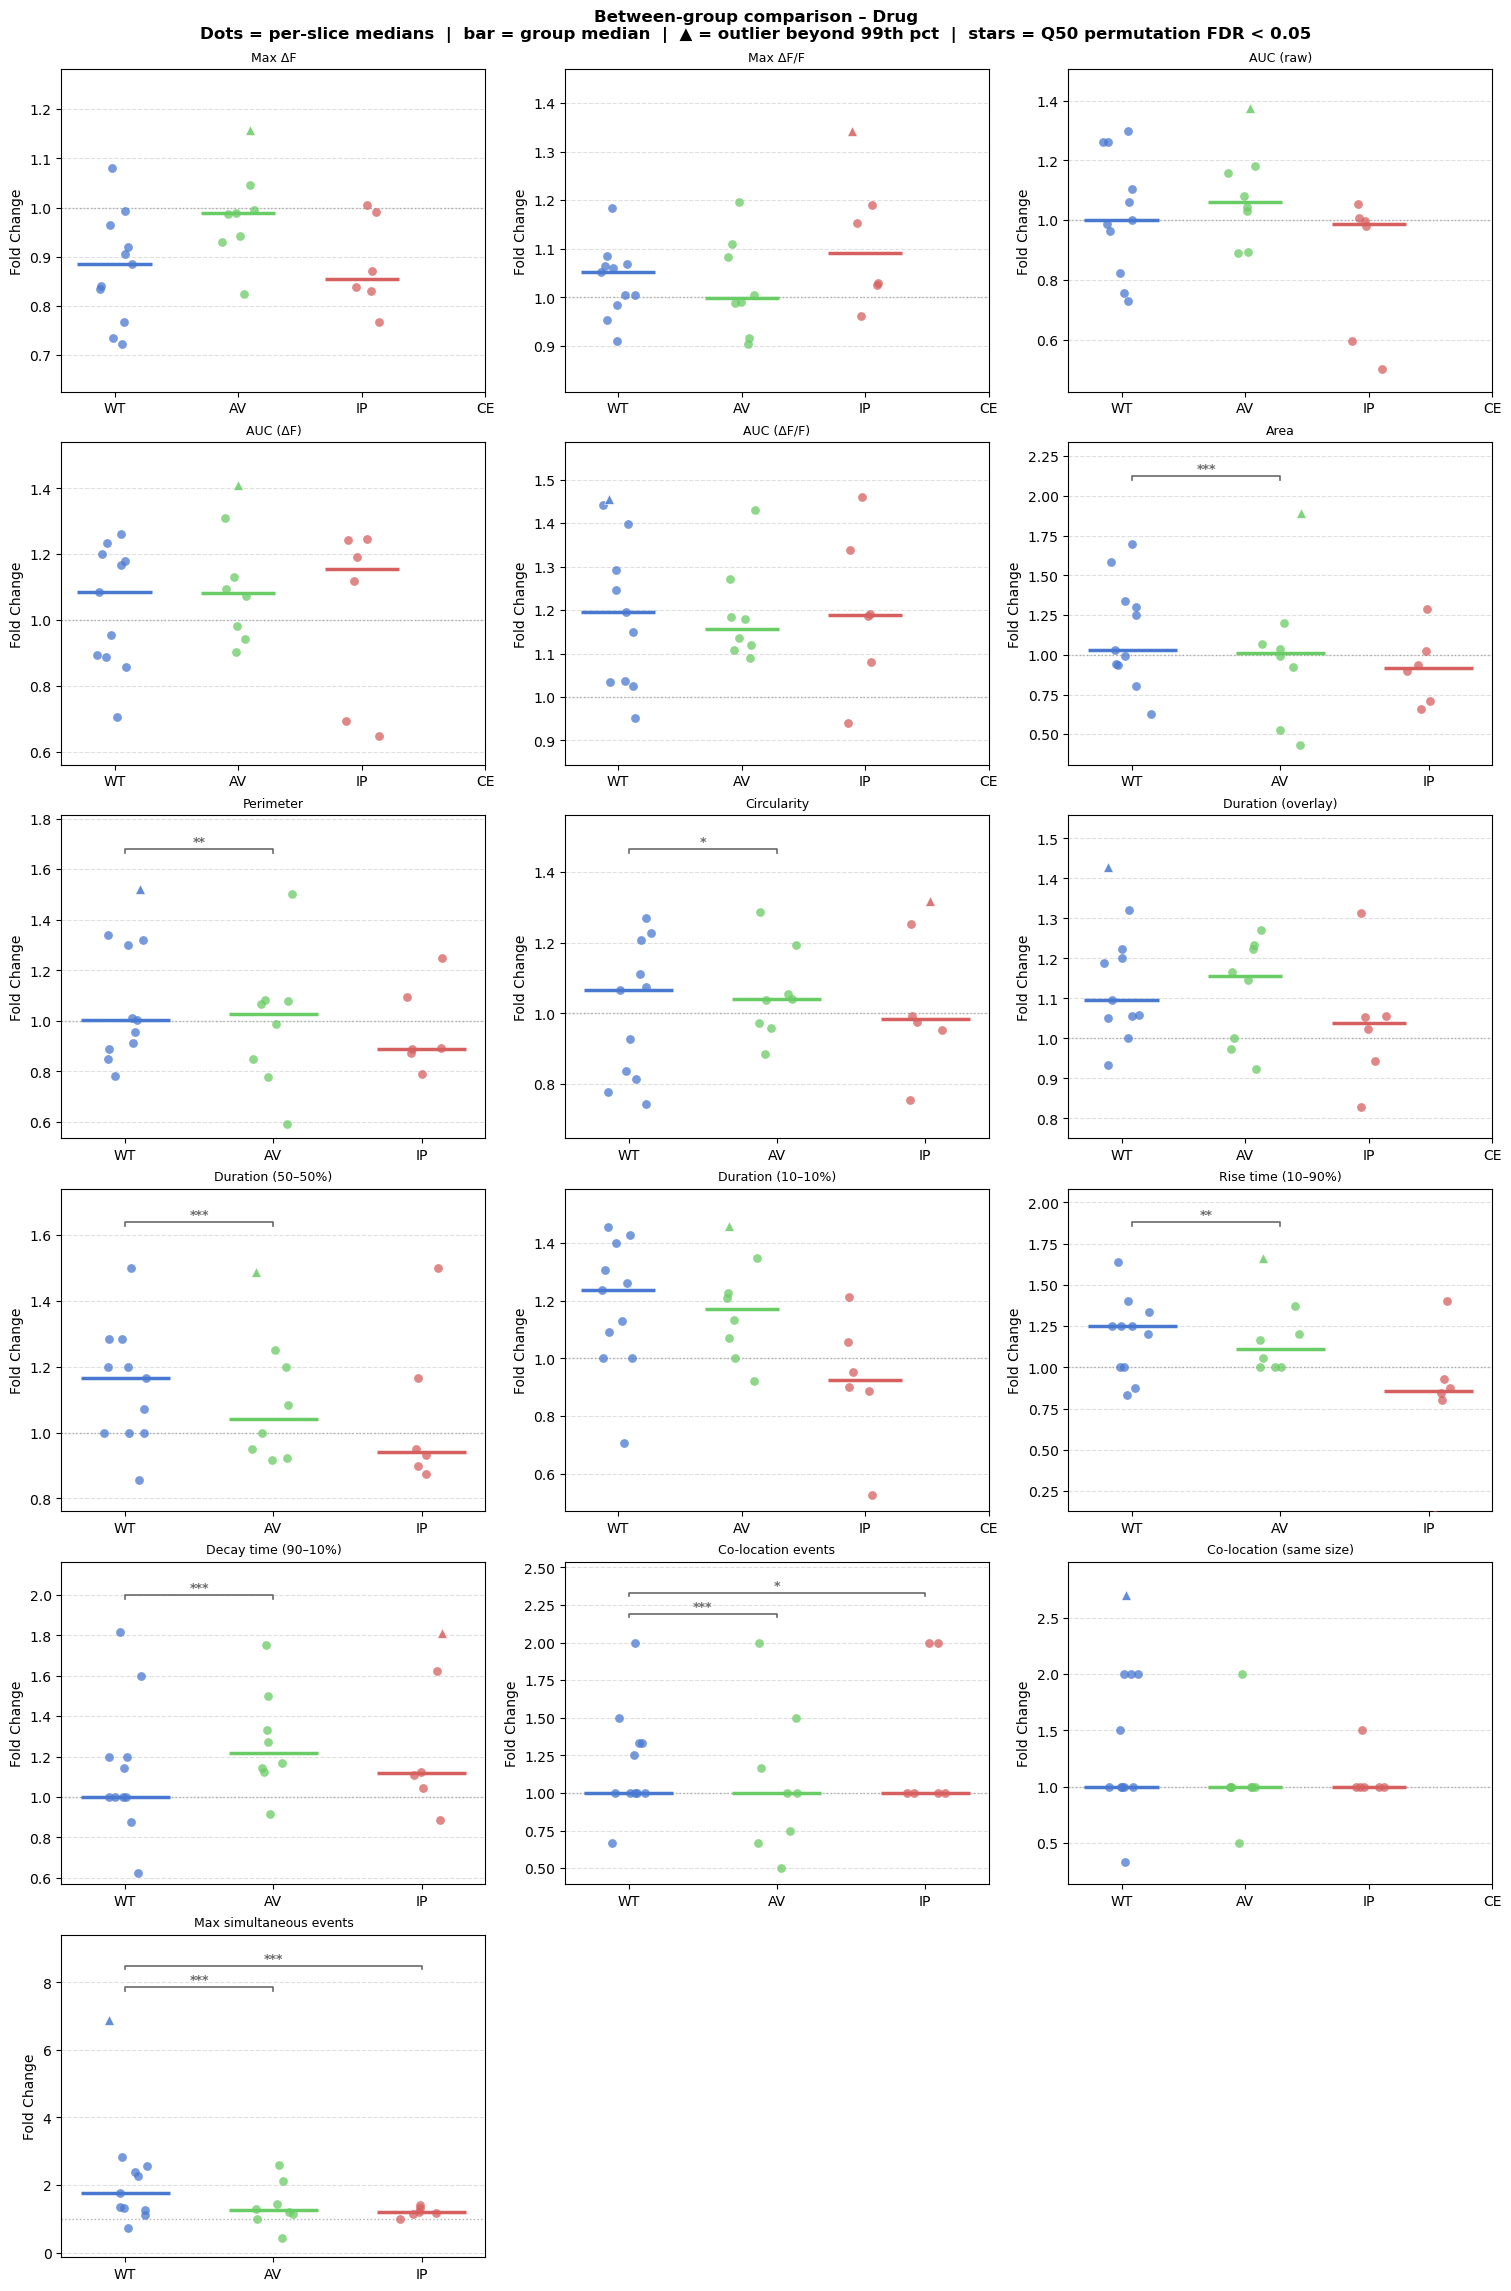

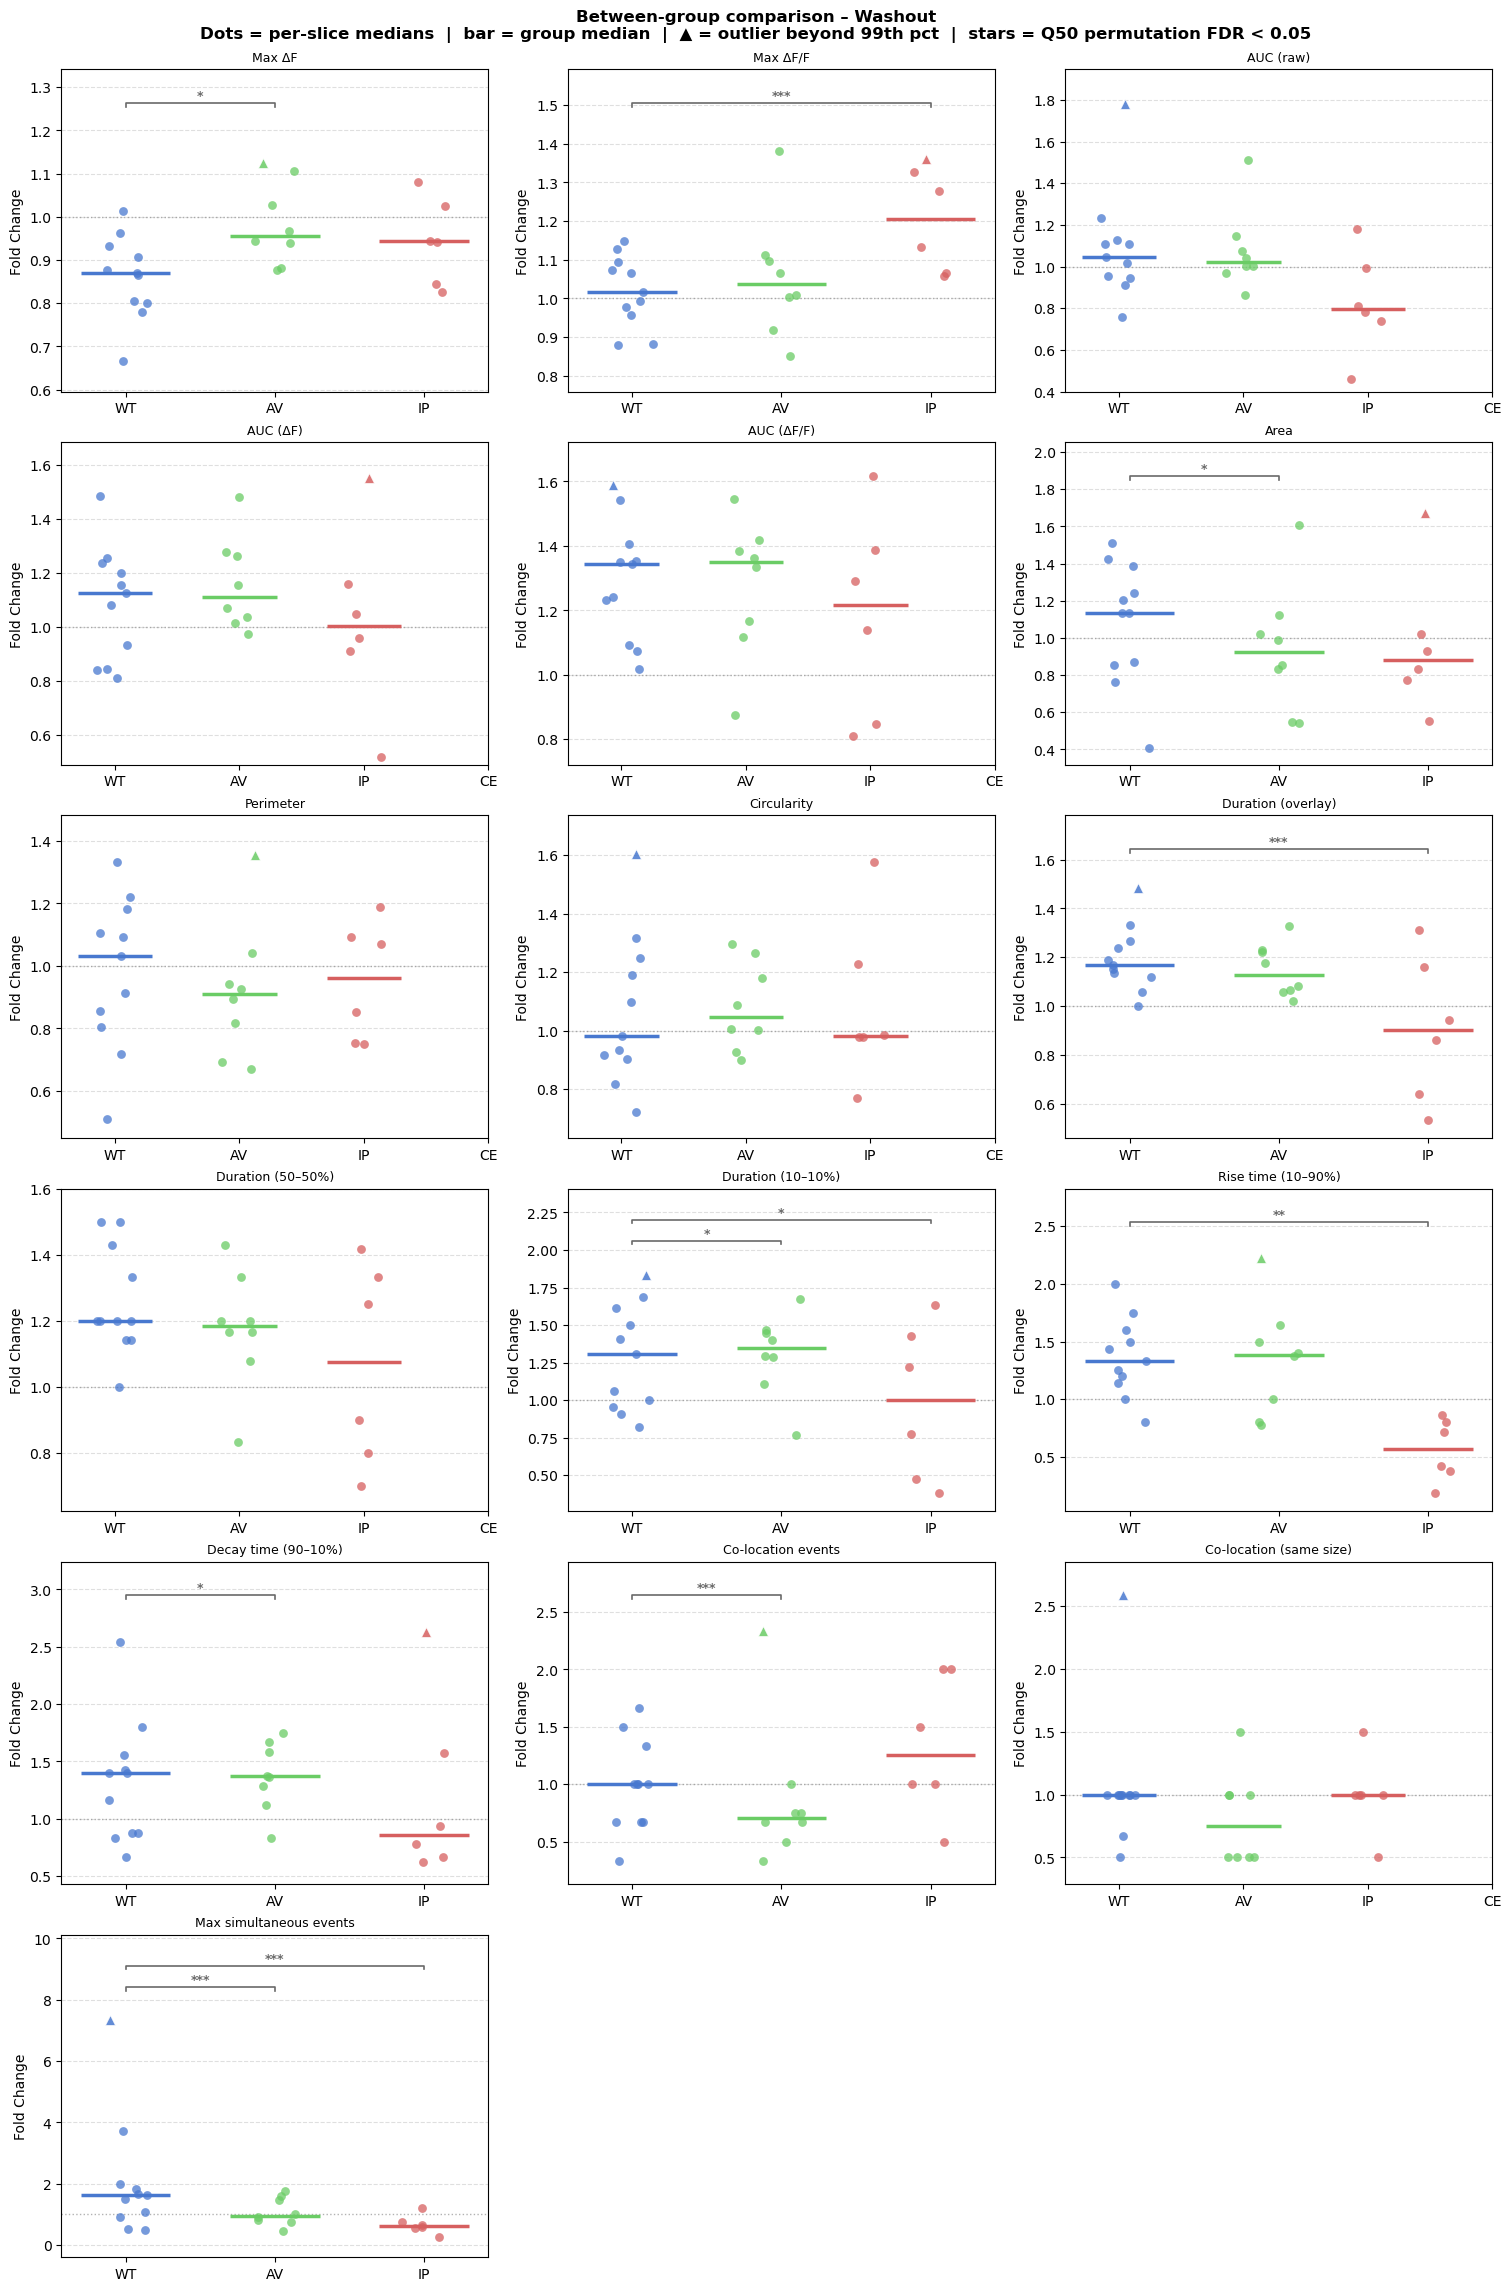


STEP 4 – Within-group timepoint plots


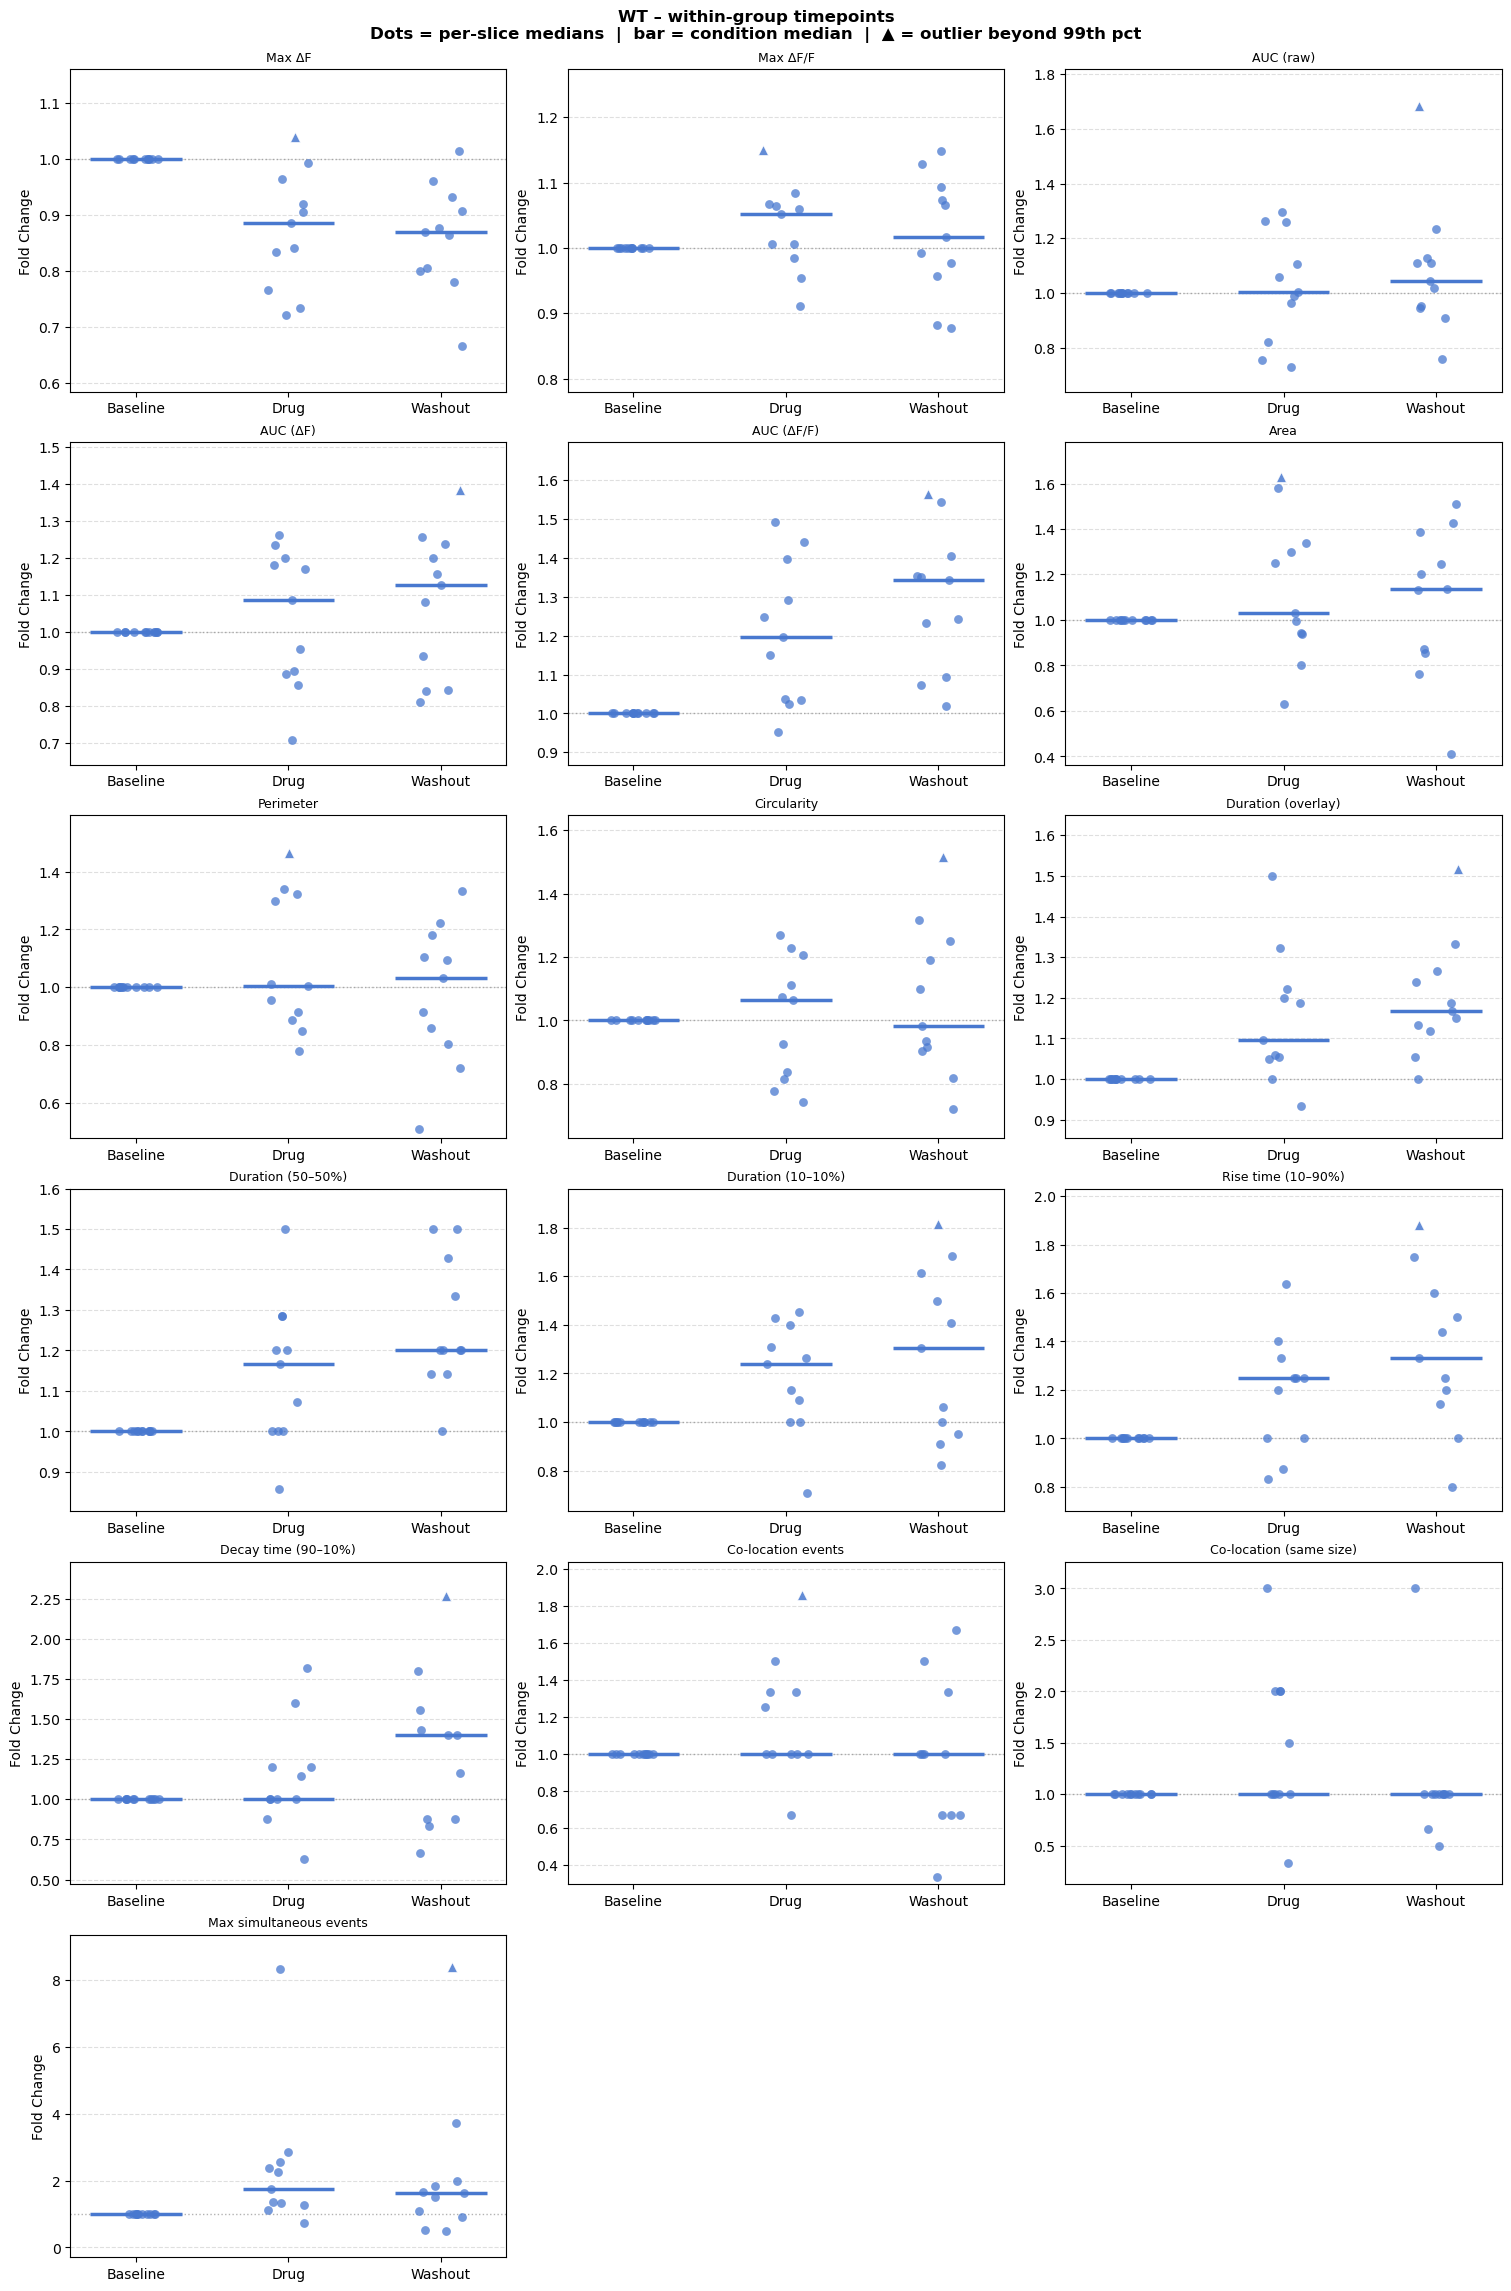

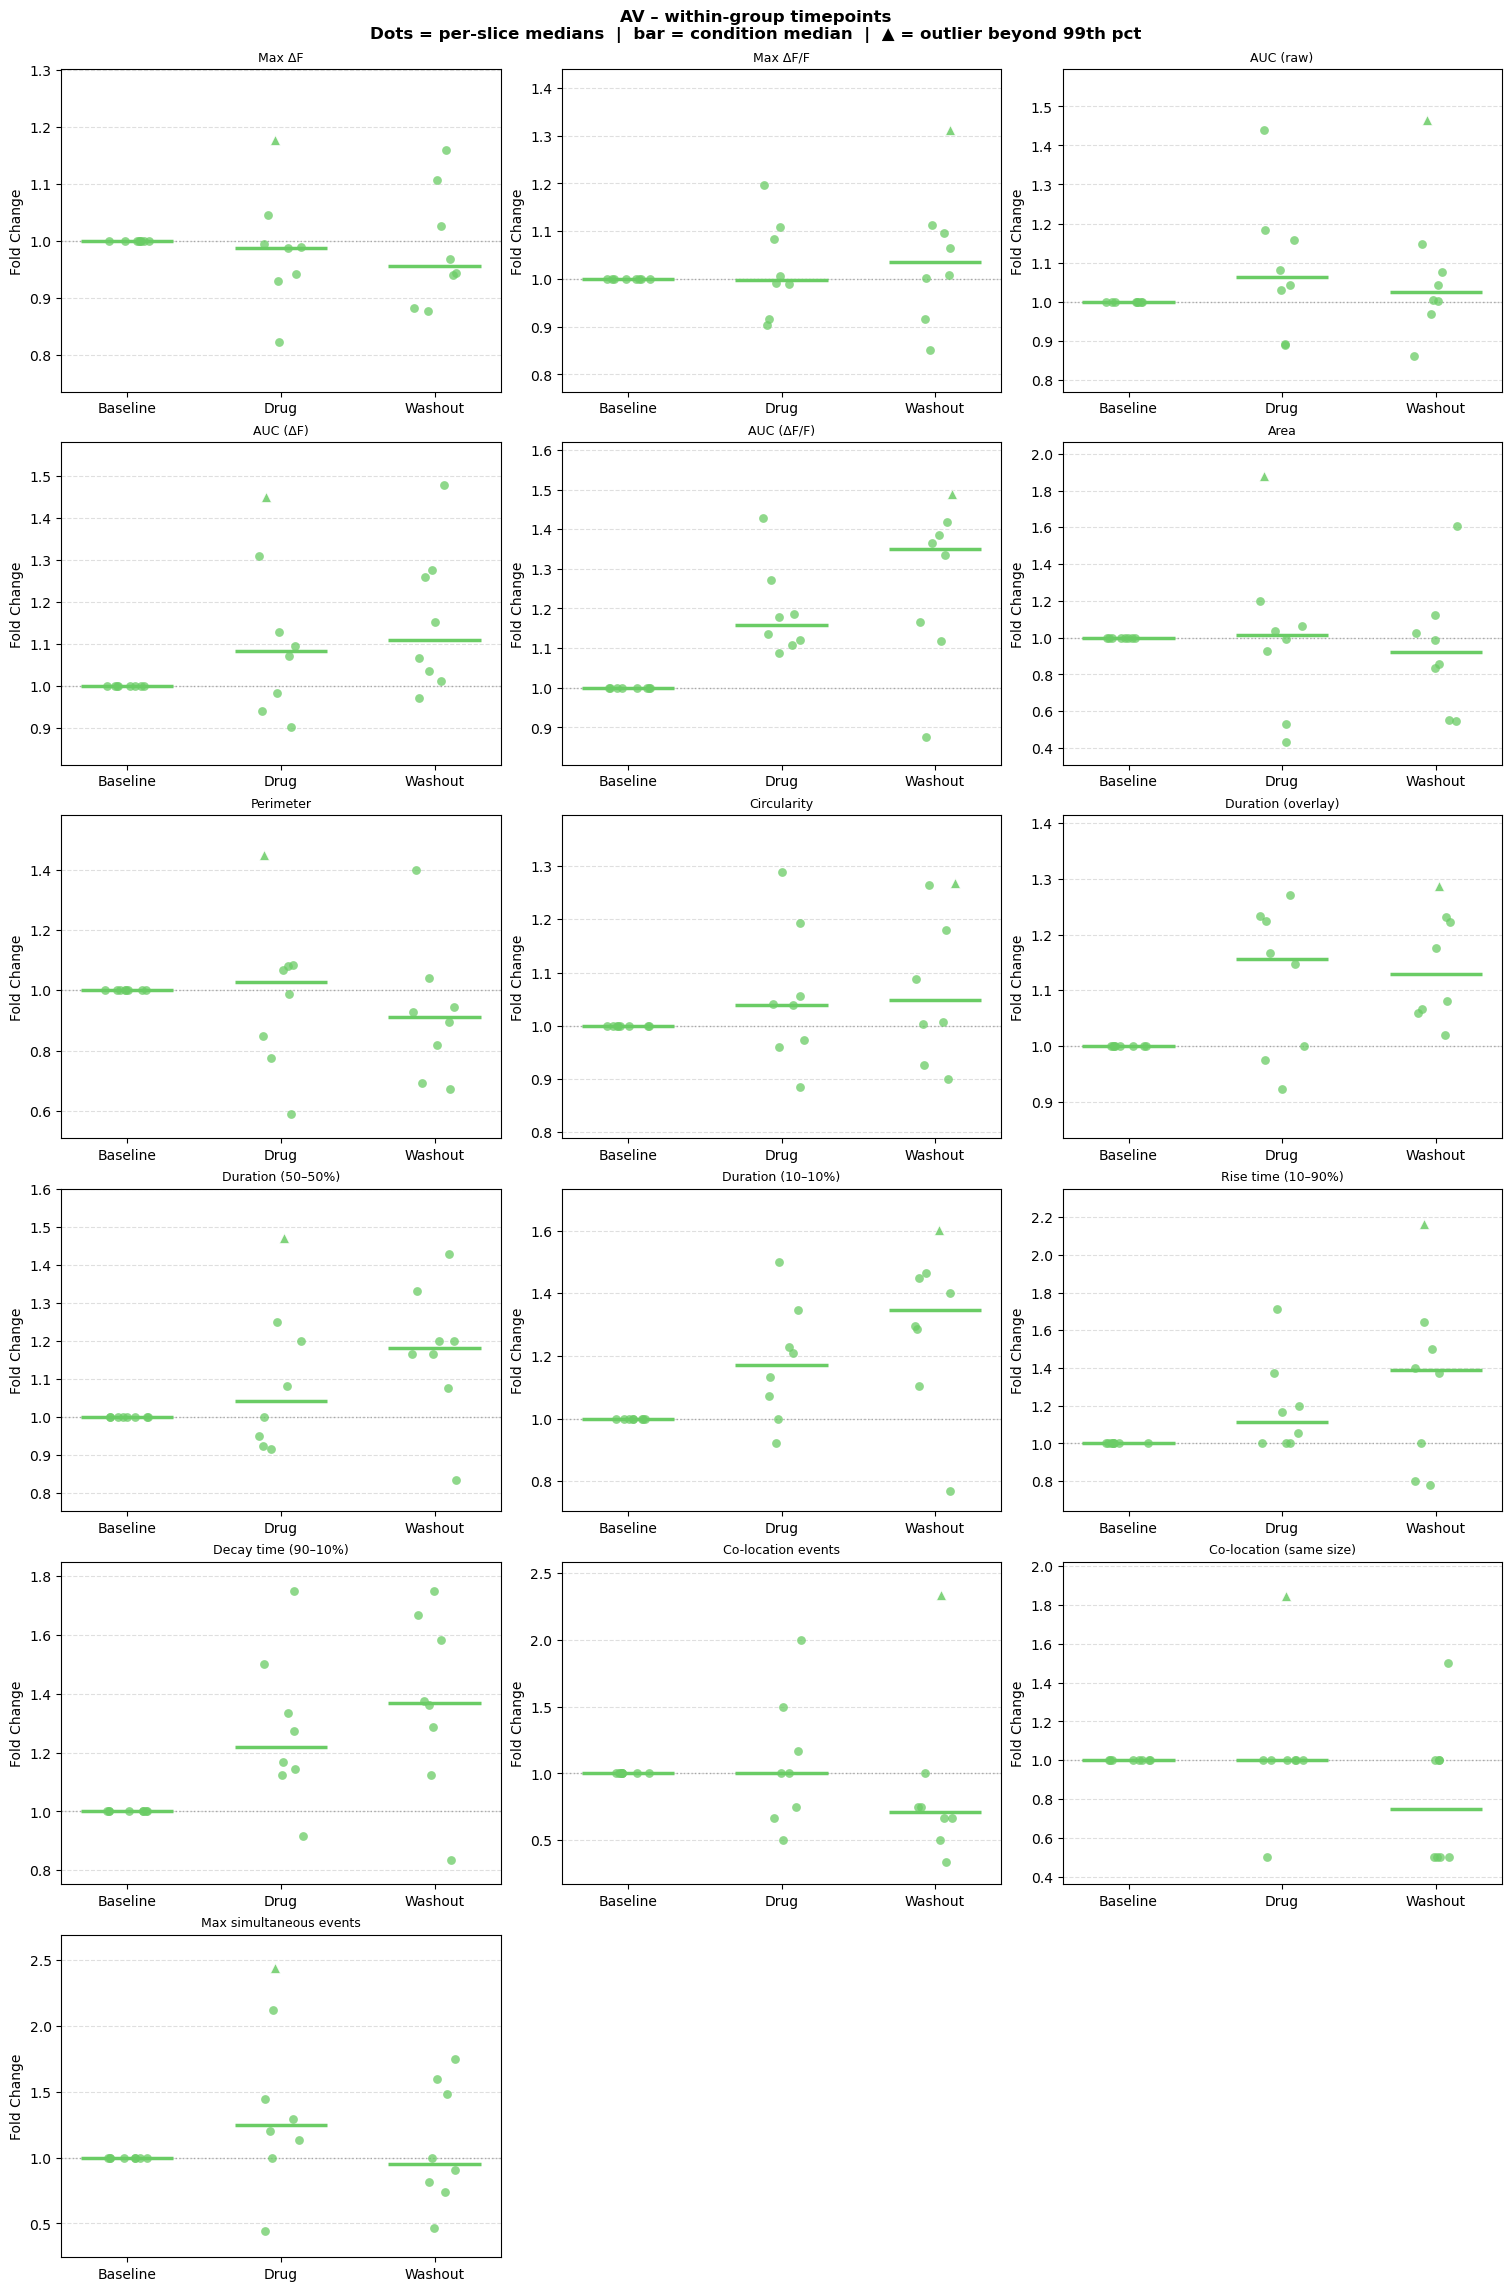

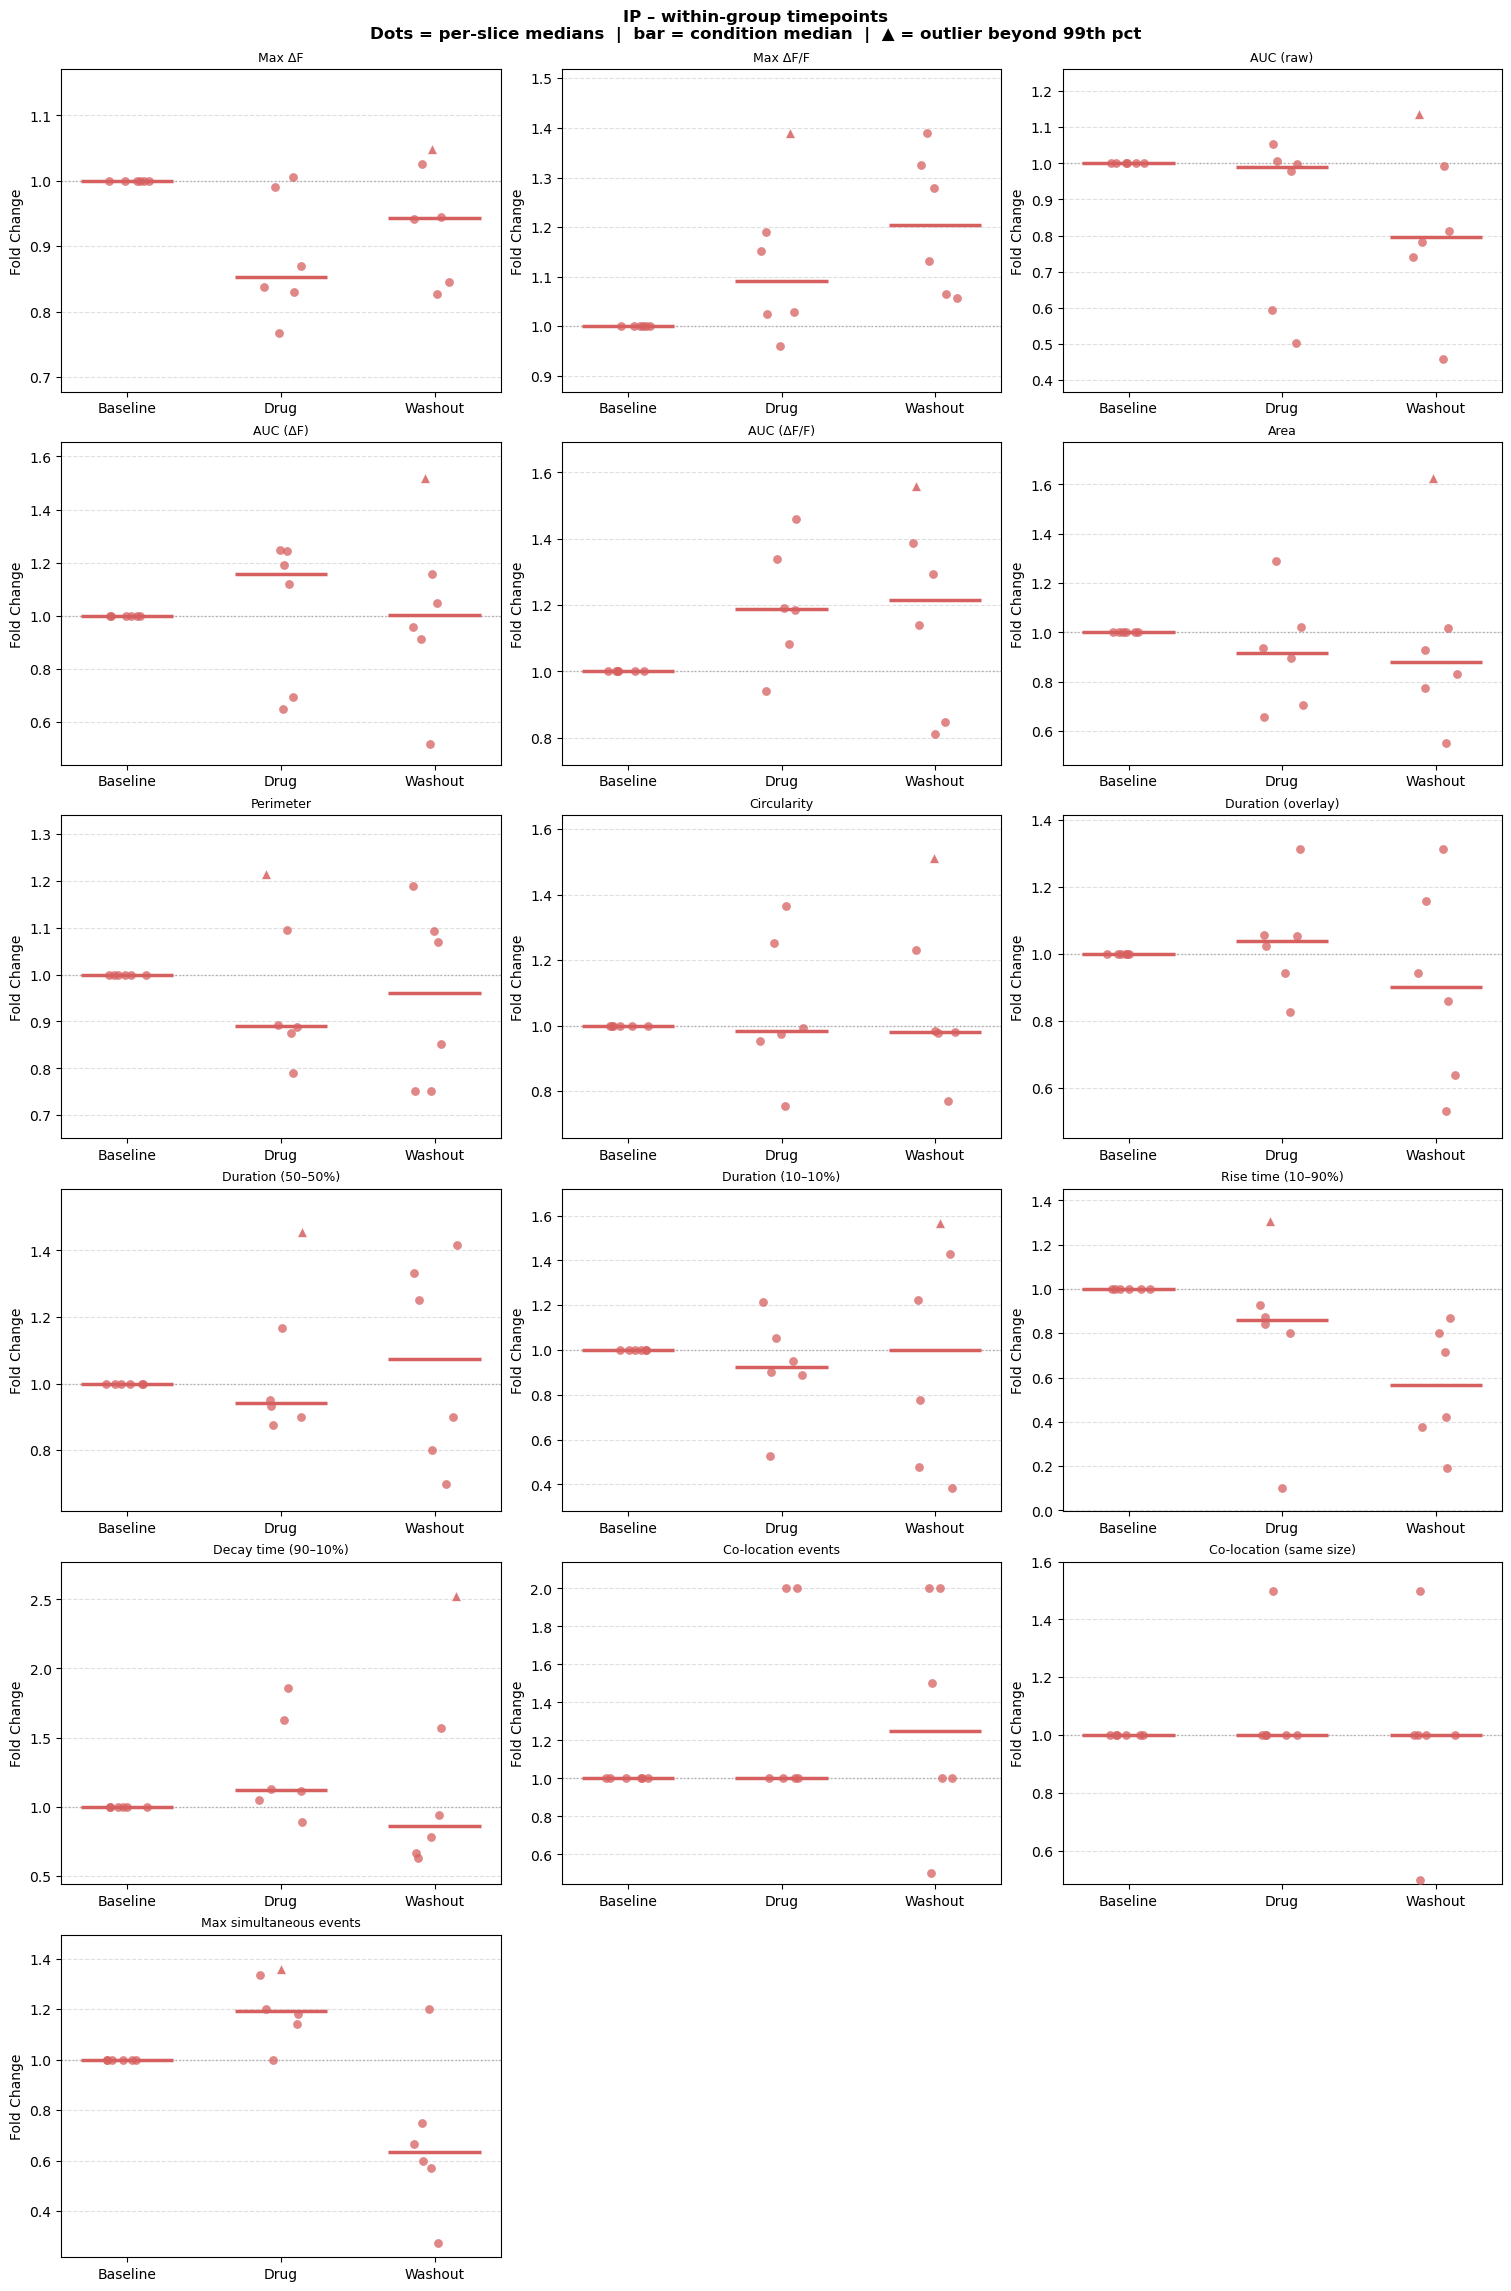


STEP 5 – Exports
  [WT] 702 frame rows | bins [5, 10, 20]
  [AV] 528 frame rows | bins [5, 10, 20]
  [IP] 182 frame rows | bins [5, 10, 20]
  [CE] 6 frame rows | bins [5, 10, 20]

Done.


In [21]:
# =============================================================================
# MAIN EXECUTION
# =============================================================================

# ── 1. Load data ──────────────────────────────────────────────────────────────
print('STEP 1 – Loading data')
group_data = {'baseline': {}, 'drug': {}, 'washout': {}}

for gname in DATA_CONFIG:
    b, d, w, *_ = load_group(gname)
    group_data['baseline'][gname] = b
    group_data['drug'][gname]     = d
    group_data['washout'][gname]  = w
    if not b.empty:
        save_csvs(b, d, w, gname, 'normalized')
        save_binned(b, d, w, gname)
    else:
        print(f'  WARNING: no valid data for {gname}')

# ── 2. Statistics ─────────────────────────────────────────────────────────────
# Quantile regression at Q50/Q75/Q90 with WT as reference.
# Run before plotting so Q50 annotations are available for the dot plots.
print('\nSTEP 2 – Quantile regression (Q50 / Q75 / Q90)')
res_dict = {}
for cond in ['drug', 'washout']:
    cond_dict = {g: group_data[cond][g] for g in QREG_GROUPS
                 if g in group_data[cond]}
    res = test_features(cond_dict, condition_name=cond.capitalize())
    print_results(res)
    res_dict[cond] = res

# ── 3. Between-group plots ────────────────────────────────────────────────────
# Dots = per-slice medians. Stars = Q50 quantile regression FDR.
print('\nSTEP 3 – Between-group plots')
for cond in ['drug', 'washout']:
    plot_group_comparison(group_data, condition=cond, res=res_dict[cond])

# ── 4. Within-group timepoint plots ──────────────────────────────────────────
print('\nSTEP 4 – Within-group timepoint plots')
for gname in DATA_CONFIG:
    if not group_data['drug'][gname].empty:
        plot_timepoints(group_data, gname)

# ── 5. Exports ────────────────────────────────────────────────────────────────
print('\nSTEP 5 – Exports')
for gname in DATA_CONFIG:
    export_frame_counts(gname)

print('\nDone.')